Fetching Macro & Market Data...


/tmp/ipykernel_1501/713674905.py:20: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(list(tickers.values()), period='5y', interval='1d', progress=False)['Close']


Training on 891 days, Testing on 297 days.

--- MODEL PERFORMANCE ON UNSEEN TEST DATA ---
Accuracy: 46.80%

Detailed Report:
              precision    recall  f1-score   support

           0       0.50      0.28      0.36       158
           1       0.45      0.68      0.54       139

    accuracy                           0.47       297
   macro avg       0.48      0.48      0.45       297
weighted avg       0.48      0.47      0.45       297



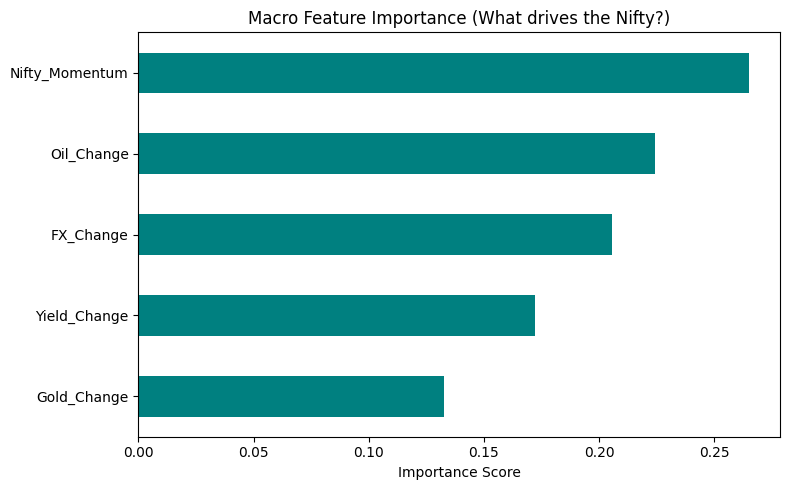

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# --- 1. DATA COLLECTION ---
print("Fetching Macro & Market Data...")
tickers = {
    'Nifty': '^NSEI',
    'USD_INR': 'INR=X',
    'Crude_Oil': 'CL=F',
    'Gold': 'GC=F',
    'US_10Y': '^TNX'
}

# Download 5 years of daily data
data = yf.download(list(tickers.values()), period='5y', interval='1d', progress=False)['Close']
data.columns = list(tickers.keys())
data.dropna(inplace=True)

if data.empty:
    print("ERROR: No data downloaded or all data was dropped after NA removal. Cannot proceed.")
    raise ValueError("No data available to process.")

# --- 2. FEATURE ENGINEERING (The Economics Part) ---
# ML models struggle with absolute prices. We need to feed it *Rates of Change*
# We will look at the 5-day (weekly) momentum of our macro variables.

features = pd.DataFrame(index=data.index)

# Calculate 5-day percentage changes for our X variables
features['Oil_Change'] = data['Crude_Oil'].pct_change(5)
features['FX_Change'] = data['USD_INR'].pct_change(5)
features['Gold_Change'] = data['Gold'].pct_change(5)

# For Yields, we usually look at absolute basis point changes, not % change
features['Yield_Change'] = data['US_10Y'].diff(5)

# Add Nifty's own recent momentum as a baseline feature
features['Nifty_Momentum'] = data['Nifty'].pct_change(5)

# --- 3. DEFINING THE TARGET (y) ---
# Question: Will the Nifty be higher 10 days from now?
lookahead = 10
data['Future_Nifty'] = data['Nifty'].shift(-lookahead)

# 1 if Future Price > Current Price, else 0
features['Target'] = np.where(data['Future_Nifty'] > data['Nifty'], 1, 0)

# Drop NaNs created by shifting and percentage changes
features.dropna(inplace=True)

if features.empty:
    print("ERROR: Features DataFrame is empty after engineering and NA removal. Cannot proceed.")
    raise ValueError("No features available to train the model.")

# Define X (Inputs) and y (Output)
X = features.drop('Target', axis=1)
y = features['Target']

# --- 4. TRAIN / TEST SPLIT ---
# In finance, we NEVER shuffle the data. We train on the past and test on the future.
split_idx = int(len(features) * 0.75) # 75% Train, 25% Test
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Add a check to ensure X_train and y_train are not empty before training
if X_train.empty or y_train.empty:
    print("ERROR: Training data (X_train or y_train) is empty. Cannot train the model.")
    raise ValueError("Empty training data.")

print(f"Training on {len(X_train)} days, Testing on {len(X_test)} days.")

# --- 5. TRAIN THE MACHINE LEARNING MODEL ---
# n_estimators = 100 trees in our forest
# max_depth = 5 prevents the model from overfitting to noise
model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# --- 6. EVALUATION & FEATURE IMPORTANCE ---
y_pred = model.predict(X_test)

print("\n--- MODEL PERFORMANCE ON UNSEEN TEST DATA ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

# Plot what the model learned was most important
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal', figsize=(8, 5))
plt.title("Macro Feature Importance (What drives the Nifty?)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()